# Model Building

**Models**: Logistic Regression, Decision Tree, Random Forest, SVC and KNN

### 1) Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,classification_report)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

### 2) Load Cleaned Data

In [8]:
df = pd.read_csv('data.csv')
print(f" Shape: {df.shape}")
df.head()

 Shape: (1000, 12)


,age,sex,bmi,systolic_pressure,glucose,cholesterol,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,69,0,23.3,114,65,87.1,1,1,1,0,0,1
1,32,0,24.8,112,100,181.1,1,7,0,1,1,1
2,89,0,44.2,113,118,91.5,1,4,0,1,1,1
3,78,0,23.3,127,95,181.1,1,5,0,0,1,1
4,38,1,41.1,117,118,133.8,0,6,0,0,1,1


### 3) Prepare Features and Target

In [9]:
base_features = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol', 'smoking', 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']

# Features de interação
df['bmi_smoking'] = df['bmi'] * df['smoking']
df['age_family_diabetes'] = df['age'] * df['family_history_diabetes']
df['age_family_hypertension'] = df['age'] * df['family_history_hypertension']
df['glucose_cholesterol'] = df['glucose'] * df['cholesterol'] / 1000
df['bmi_physical'] = df['bmi'] * (2 - df['physical_activity'])

# Features categóricas
df['bmi_obese'] = (df['bmi'] >= 30).astype(int)
df['bp_high'] = (df['systolic_pressure'] >= 130).astype(int)
df['glucose_high'] = (df['glucose'] >= 100).astype(int)
df['cholesterol_high'] = (df['cholesterol'] >= 200).astype(int)
df['age_senior'] = (df['age'] >= 60).astype(int)

interaction_features = ['bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                        'glucose_cholesterol', 'bmi_physical']
categorical_features = ['bmi_obese', 'bp_high', 'glucose_high', 
                        'cholesterol_high', 'age_senior']

all_features = base_features + interaction_features + categorical_features

X = df[all_features].copy()
y_diabetes = df['diabetes_risk']
y_hypertension = df['hypertension_risk']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Targets:")
print(f"-Diabetes: {y_diabetes.sum()} positives ({y_diabetes.mean()*100:.1f}%)")
print(f"-Hypertension: {y_hypertension.sum()} positives ({y_hypertension.mean()*100:.1f}%)")

X_train, X_test, y_diab_train, y_diab_test = train_test_split(X, y_diabetes, test_size=0.2, random_state=67, stratify=y_diabetes)

_, _, y_hyp_train, y_hyp_test = train_test_split(X, y_hypertension, test_size=0.2, random_state=67, stratify=y_hypertension)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Feature scaling

numeric_features = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol',
                    'bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                    'glucose_cholesterol', 'bmi_physical']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# SMOTE balancing (SVM and KNN)
smote_diab = SMOTE(random_state=67)
X_train_balanced_diab, y_diab_train_balanced = smote_diab.fit_resample(X_train_scaled, y_diab_train)

smote_hyp = SMOTE(random_state=67)
X_train_balanced_hyp, y_hyp_train_balanced = smote_hyp.fit_resample(X_train_scaled, y_hyp_train)

Features: 19
Samples: 1000
Targets:
-Diabetes: 710 positives (71.0%)
-Hypertension: 844 positives (84.4%)
Train: 800 samples
Test: 200 samples


### 4) Train Models

In [10]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=67, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=67, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=67),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=67),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

diabetes_models = {}
hypertension_models = {}
diabetes_results = []
hypertension_results = []
print("-"*50)
print("Training models for Diabetes:")
print("-"*50)
# Diabetes models
for name, model in models.items():
    print(f"Training {name}...")
    
    # SVM and KNN use SMOTE
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_diab, y_diab_train_balanced)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_scaled, y_diab_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_diab_test, y_pred)
    prec = precision_score(y_diab_test, y_pred)
    rec = recall_score(y_diab_test, y_pred)
    f1 = f1_score(y_diab_test, y_pred)
    auc = roc_auc_score(y_diab_test, y_proba)
    
    diabetes_models[name] = model
    diabetes_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f} \n")

print("-"*50)
print("Training models for Hypertension:")
print("-"*50)
# Hypertension models
for name, model in models.items():
    print(f"Training {name}...")
    
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_hyp, y_hyp_train_balanced)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_scaled, y_hyp_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_hyp_test, y_pred)
    prec = precision_score(y_hyp_test, y_pred)
    rec = recall_score(y_hyp_test, y_pred)
    f1 = f1_score(y_hyp_test, y_pred)
    auc = roc_auc_score(y_hyp_test, y_proba)
    
    hypertension_models[name] = model
    hypertension_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f}")

--------------------------------------------------
Training models for Diabetes:
--------------------------------------------------
Training Logistic Regression...
Accuracy: 0.8900 | ROC-AUC: 0.9585 | F1: 0.9209 

Training Decision Tree...
Accuracy: 0.8600 | ROC-AUC: 0.8078 | F1: 0.9041 

Training Random Forest...
Accuracy: 0.8950 | ROC-AUC: 0.9472 | F1: 0.9293 

Training SVM...
Accuracy: 0.8800 | ROC-AUC: 0.9469 | F1: 0.9137 

Training KNN...
Accuracy: 0.8200 | ROC-AUC: 0.8685 | F1: 0.8676 

--------------------------------------------------
Training models for Hypertension:
--------------------------------------------------
Training Logistic Regression...
Accuracy: 0.8050 | ROC-AUC: 0.8754 | F1: 0.8754
Training Decision Tree...
Accuracy: 0.8150 | ROC-AUC: 0.6236 | F1: 0.8915
Training Random Forest...
Accuracy: 0.8100 | ROC-AUC: 0.8435 | F1: 0.8902
Training SVM...
Accuracy: 0.8100 | ROC-AUC: 0.8540 | F1: 0.8834
Training KNN...
Accuracy: 0.7600 | ROC-AUC: 0.7684 | F1: 0.8462


### 5) Model Comparison


DIABETES RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.958475  0.920863 0.901408   0.941176
      Decision Tree 0.807795  0.904110 0.929577   0.880000
      Random Forest 0.947183  0.929293 0.971831   0.890323
                SVM 0.946940  0.913669 0.894366   0.933824
                KNN 0.868504  0.867647 0.830986   0.907692

HYPERTENSION RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.875358  0.875399 0.810651   0.951389
      Decision Tree 0.623592  0.891496 0.899408   0.883721
      Random Forest 0.843482  0.890173 0.911243   0.870056
                SVM 0.853980  0.883436 0.852071   0.917197
                KNN 0.768372  0.846154 0.781065   0.923077


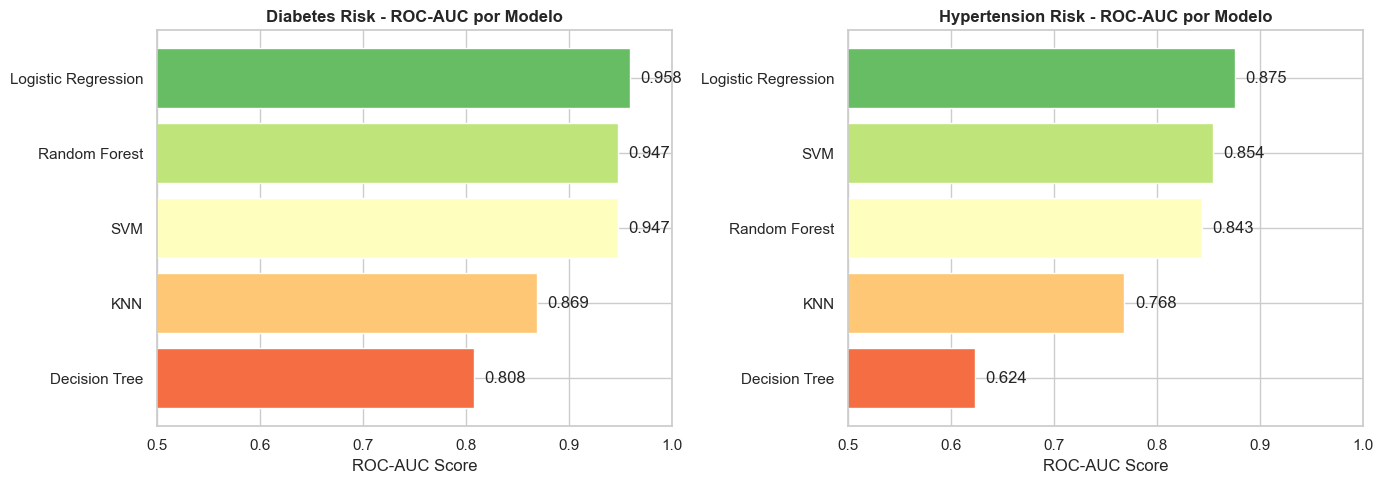

In [11]:
diab_df = pd.DataFrame(diabetes_results)
hyp_df = pd.DataFrame(hypertension_results)

best_diab_model = diab_df.loc[diab_df['ROC-AUC'].idxmax(), 'Model']
best_diab_auc = diab_df['ROC-AUC'].max()

best_hyp_model = hyp_df.loc[hyp_df['ROC-AUC'].idxmax(), 'Model']
best_hyp_auc = hyp_df['ROC-AUC'].max()

print("\n" + "="*60)
print("DIABETES RISK - Models Performance")
print("="*60)
print(diab_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

print("\n" + "="*60)
print("HYPERTENSION RISK - Models Performance")
print("="*60)
print(hyp_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diabetes
ax = axes[0]
diab_sorted = diab_df.sort_values('ROC-AUC', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(diab_sorted)))
bars = ax.barh(diab_sorted['Model'], diab_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Diabetes Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, diab_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Hypertension
ax = axes[1]
hyp_sorted = hyp_df.sort_values('ROC-AUC', ascending=True)
bars = ax.barh(hyp_sorted['Model'], hyp_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Hypertension Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, hyp_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()